# Day 17: Text Embeddings & Semantic Search 

**Date:** July, 8 2026  
**Intern:** Fatima rasool  
**Topic:** Text Embeddings & Semantic Search 

### 1. What are Embeddings?  
An embedding is a numerical representation (vector) of text that captures its meaning, not just the words.
### 2. How Embeddings Work
1. input
2. neutral network -> process the input
3. output
### 3. Embedding Models  
One common family of models is the OpenAI text-embedding-3-small and OpenAI text-embedding-3-large models.
text-embedding-3-small -> 512  and 1536
text-embedding-3-large -> 3072
### 4. Similarity Metrics
Once we have vectors, we need a way to compare them.
- A. Cosine Similarity (Most Common) -> compare angle between two vector  **Range:** (-1 1) after normalization 0 and 1
- B. Dot Product-> Simply multiplies matching values and adds them together
- C. Euclidean Distance-> Measures the straight-line distance between vectors.
### 5. Use Cases
semantic serach -> normal search
embedded search ->  search base on vector
### Why Vector Databases?
A vector database stores embeddings and can quickly find the nearest vectors.
**Examples**: include Pinecone, Weaviate, Qdrant, and Milvus.





# Task 1: Generate & Compare Embeddings 


In [1]:
%pip install openai numpy scikit-learn --break-system-packages

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\zraso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
%pip install -U google-genai

   ---------------------------------------- 0.0/958.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/958.0 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/958.0 kB ? eta -:--:--
   --------------------- ------------------ 524.3/958.0 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 958.0/958.0 kB 1.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\zraso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Embedding Dimension: 3072

Dog vs Puppy
0.7485482262304549

Dog vs Car
0.6308766225070089

Similarity Matrix
[[1.         0.74854823 0.74689359 0.64591592 0.63087662 0.64420637
  0.63976816 0.63071773 0.61229817 0.64258969]
 [0.74854823 1.         0.67966268 0.71755705 0.59588966 0.65027309
  0.57358537 0.61146821 0.60730329 0.61618348]
 [0.74689359 0.67966268 1.         0.72979763 0.65623862 0.64169563
  0.63449011 0.64471836 0.6299099  0.67352184]
 [0.64591592 0.71755705 0.72979763 1.         0.60701262 0.61483711
  0.59421281 0.64444324 0.60825991 0.62025331]
 [0.63087662 0.59588966 0.65623862 0.60701262 1.         0.64895853
  0.64688379 0.6139741  0.59604069 0.66441433]
 [0.64420637 0.65027309 0.64169563 0.61483711 0.64895853 1.
  0.65323902 0.61508789 0.60594632 0.61686699]
 [0.63976816 0.57358537 0.63449011 0.59421281 0.64688379 0.65323902
  1.         0.650445   0.60675924 0.62189705]
 [0.63071773 0.61146821 0.64471836 0.64444324 0.6139741  0.61508789
  0.650445   1.         0.

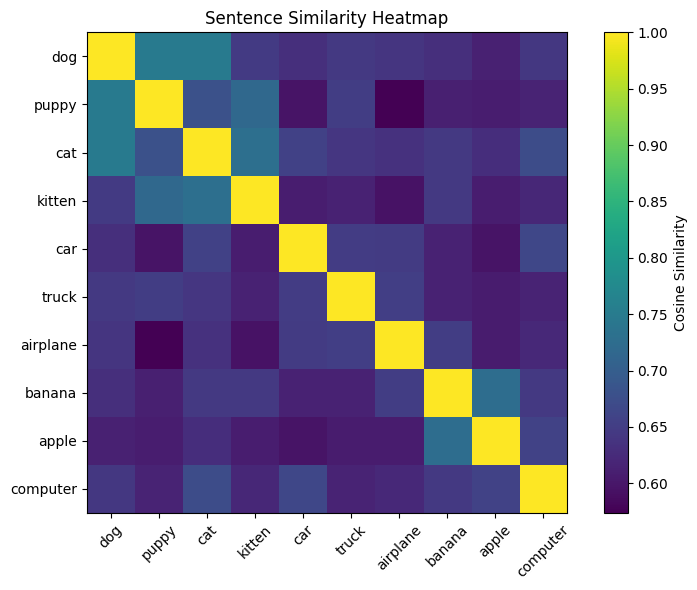

In [ ]:
import os
from dotenv import load_dotenv
from google import genai

import math
import numpy as np
import matplotlib.pyplot as plt
# Load environment variables
load_dotenv()

# Create Gemini client
client = genai.Client(api_key=os.getenv("GEMENI_API"))

sentences = [
  "dog",
    "puppy",
    "cat",
    "kitten",
    "car",
    "truck",
    "airplane",
    "banana",
    "apple",
    "computer"
]

response = client.models.embed_content(
    model="gemini-embedding-001",
    contents=sentences
)

embeddings = []

for embedding in response.embeddings:
    embeddings.append(embedding.values)
print("Embedding Dimension:", len(embeddings[0]))

# -----------------------------
# Cosine Similarity (From Scratch)
# -----------------------------
def cosine_similarity(vec1, vec2):

    # Dot Product
    dot = 0
    for a, b in zip(vec1, vec2):
        dot += a * b

    # Magnitude of first vector
    mag1 = 0
    for x in vec1:
        mag1 += x ** 2
    mag1 = math.sqrt(mag1)

    # Magnitude of second vector
    mag2 = 0
    for y in vec2:
        mag2 += y ** 2
    mag2 = math.sqrt(mag2)

    # Prevent division by zero
    if mag1 == 0 or mag2 == 0:
        return 0

    return dot / (mag1 * mag2)

# -----------------------------
# Compare Similar Words
# -----------------------------
dog = embeddings[0]
puppy = embeddings[1]

score = cosine_similarity(dog, puppy)

print("\nDog vs Puppy")
print(score)


car = embeddings[4]

score = cosine_similarity(dog, car)

print("\nDog vs Car")
print(score)


n = len(embeddings)

matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matrix[i][j] = cosine_similarity(
            embeddings[i],
            embeddings[j]
        )

print("\nSimilarity Matrix")
print(matrix)

# -----------------------------
# Heatmap
# -----------------------------
plt.figure(figsize=(8, 6))

plt.imshow(matrix, cmap="viridis")

plt.colorbar(label="Cosine Similarity")

plt.xticks(range(n), sentences, rotation=45)

plt.yticks(range(n), sentences)

plt.title("Sentence Similarity Heatmap")

plt.tight_layout()

plt.show()

## zip() function
zip function join the list,tuple,set
rule:
1. both lists or tuples has same length
2. return alway a tuple


In [9]:
import os
import math
from dotenv import load_dotenv
from google import genai

# -------------------------
# Load API Key
# -------------------------
load_dotenv()

client = genai.Client(
    api_key=os.getenv("GEMENI_API")
)

# -------------------------
# Knowledge Base
# -------------------------

knowledge_base = [

# AI
"Machine learning teaches computers from data.",
"Deep learning uses neural networks.",
"Artificial Intelligence automates tasks.",
"Python is popular for AI.",
"Data science analyzes large datasets.",

# Health
"Vegetables contain many vitamins.",
"Exercise improves heart health.",
"Drinking water keeps the body hydrated.",
"Healthy food increases energy.",
"Fruits are rich in fiber.",

# Programming
"Python is easy to learn.",
"Java is object oriented.",
"C++ is fast.",
"JavaScript powers websites.",
"Programming improves problem solving.",

# Sports
"Football is the world's most popular sport.",
"Cricket is loved in Pakistan.",
"Tennis is played with rackets.",
"Swimming is excellent exercise.",
"Running builds endurance.",

# Space
"The Earth revolves around the Sun.",
"Mars is called the Red Planet.",
"The Moon orbits Earth.",
"Saturn has beautiful rings.",
"Astronauts explore space.",

# Food
"Pizza is an Italian food.",
"Biryani is famous in Pakistan.",
"Rice contains carbohydrates.",
"Eggs provide protein.",
"Milk contains calcium.",

# Technology
"Cloud computing stores data online.",
"Cybersecurity protects computer systems.",
"Databases store information.",
"APIs connect software systems.",
"Robots automate manufacturing.",

# Animals
"Dogs are loyal animals.",
"Cats are independent pets.",
"Lions live in Africa.",
"Elephants are intelligent mammals.",
"Birds can fly.",

# Education
"Students learn mathematics.",
"Teachers guide students.",
"Universities offer degrees.",
"Books improve knowledge.",
"Online learning is growing.",

# Business
"Marketing attracts customers.",
"Startups focus on innovation.",
"Companies hire employees.",
"Managers lead teams.",
"E-commerce enables online shopping."
]

# -------------------------
# Generate Embeddings
# -------------------------

response = client.models.embed_content(
    model="gemini-embedding-001",
    contents=knowledge_base
)

embeddings = [e.values for e in response.embeddings]

# Store text + embedding

database = []

for text, emb in zip(knowledge_base, embeddings):

    database.append({

        "text": text,

        "embedding": emb

    })

print("Knowledge Base Created!")

# -------------------------
# Cosine Similarity
# -------------------------

def cosine_similarity(a, b):

    dot = sum(x*y for x, y in zip(a, b))

    mag1 = math.sqrt(sum(x*x for x in a))

    mag2 = math.sqrt(sum(y*y for y in b))

    if mag1 == 0 or mag2 == 0:

        return 0

    return dot / (mag1 * mag2)

# -------------------------
# Semantic Search
# -------------------------

def semantic_search(query, top_k=3):

    query_embedding = client.models.embed_content(

        model="gemini-embedding-001",

        contents=query

    ).embeddings[0].values

    scores = []

    for item in database:

        score = cosine_similarity(

            query_embedding,

            item["embedding"]

        )

        scores.append(

            (item["text"], score)

        )

    scores.sort(

        key=lambda x: x[1],

        reverse=True

    )

    return scores[:top_k]



print("\nQuery : machine learning algorithms\n")

results = semantic_search(

    "machine learning algorithms"

)

for text, score in results:

    print(f"{score:.3f}  --> {text}")



print("\nQuery : healthy food recipes\n")

results = semantic_search(

    "healthy food recipes"

)

for text, score in results:

    print(f"{score:.3f}  --> {text}")

Knowledge Base Created!

Query : machine learning algorithms

0.699  --> Machine learning teaches computers from data.
0.616  --> Deep learning uses neural networks.
0.605  --> Artificial Intelligence automates tasks.

Query : healthy food recipes

0.715  --> Healthy food increases energy.
0.596  --> Pizza is an Italian food.
0.592  --> Vegetables contain many vitamins.


## Task 3: Document Similarity Finder

- The sentence-transformers library is a powerful Python framework designed to generate dense vector embeddings for sentences, paragraphs, and images. 
- sk-learn is use for -> 1. [Preprocessing]              2. [Model Selection]              3. [Data Modeling]
- TSNE -> convert large dimention into 2 that can humam visualize



In [10]:
%pip install sentence-transformers scikit-learn matplotlib pandas

  Using cached hf_xet-1.5.1-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -:--:--
   --------------------------------- ---- 524.3/596.4 kB 985.5 kB/s eta 0:00:01
   -------------------------------------- 596.4/596.4 kB 971.7 kB/s eta 0:00:00
   


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\zraso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Loaded Documents

0 Artificial intelligence is transforming healthcare through disease prediction.
1 Machine learning helps doctors predict diseases earlier.
2 Football is one of the most popular sports worldwide.
3 Soccer attracts millions of fans every year.
4 Deep learning is a branch of machine learning.
5 Neural networks are used in deep learning.
6 Cooking healthy meals improves overall wellness.
7 Preparing nutritious food helps maintain good health.
8 Artificial intelligence is transforming healthcare through disease prediction.
9 Python is a popular programming language for AI.
10 Python is widely used in machine learning and data science.
11 Cats are popular household pets.
12 Dogs are loyal animals and great companions.
13 Natural language processing enables computers to understand text.
14 Chatbots use natural language processing techniques.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4864.85it/s]



Embedding Shape:
(15, 384)

Similarity Matrix
[[ 9.99999940e-01  7.28262722e-01  1.36991009e-01  1.02710351e-01
   3.84246796e-01  3.20595115e-01  1.79945737e-01  1.63913593e-01
   9.99999940e-01  3.21933120e-01  2.77005196e-01 -3.29440869e-02
   1.31133962e-02  2.42476389e-01  2.44622305e-01]
 [ 7.28262722e-01  9.99999821e-01  5.94531335e-02  3.45831625e-02
   3.89615923e-01  3.46714258e-01  2.02082932e-01  2.71598607e-01
   7.28262722e-01  2.08862677e-01  2.99677044e-01 -6.96272179e-02
  -1.27319945e-02  1.98219955e-01  1.43498629e-01]
 [ 1.36991009e-01  5.94531335e-02  1.00000012e+00  6.09684408e-01
   1.40277958e-02  9.64322884e-04  1.08811736e-01  4.99419309e-02
   1.36991009e-01  1.98119670e-01  1.36284471e-01  2.96489596e-01
   1.12156257e-01  4.22669351e-02 -2.73267552e-02]
 [ 1.02710351e-01  3.45831625e-02  6.09684408e-01  9.99999642e-01
  -5.60515909e-04 -7.14577409e-03  7.55744129e-02  8.69604051e-02
   1.02710351e-01  1.35199949e-01  1.15409970e-01  1.70060784e-01
   1.536

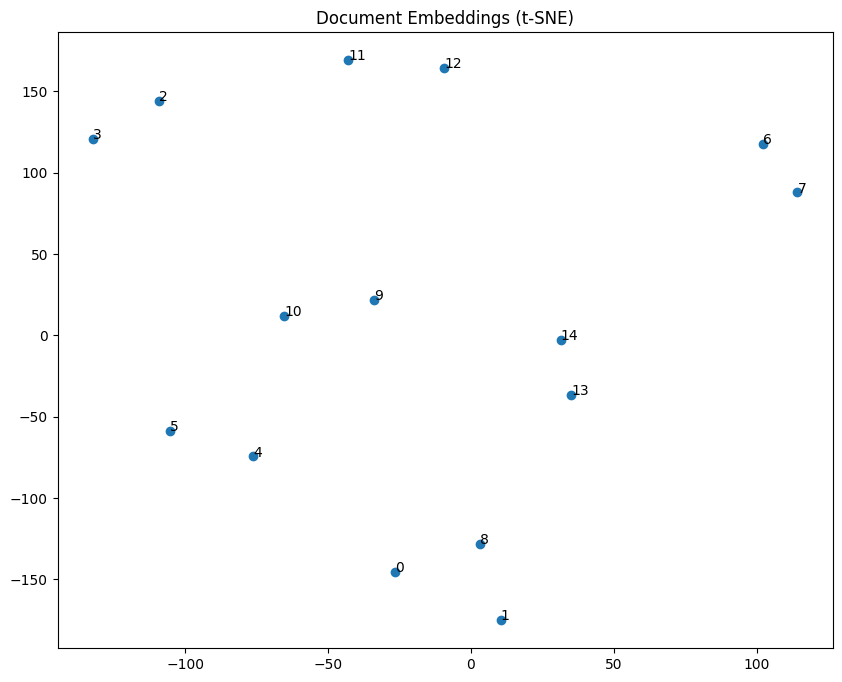

In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np


with open("documents.txt", "r", encoding="utf-8") as file:
    documents = file.read().splitlines()

print("Loaded Documents\n")

for i, doc in enumerate(documents):
    print(i, doc)


model = SentenceTransformer("all-MiniLM-L6-v2")

# -----------------------------
# Generate Embeddings
# -----------------------------
embeddings = model.encode(documents)

print("\nEmbedding Shape:")
print(embeddings.shape)


similarity_matrix = cosine_similarity(embeddings)

print("\nSimilarity Matrix")

print(similarity_matrix)

# -----------------------------
# Find Similar Documents
# -----------------------------
threshold = 0.75

print("\nSimilar Documents")

for i in range(len(documents)):
    for j in range(i + 1, len(documents)):

        score = similarity_matrix[i][j]

        if score >= threshold:
            print(f"{i}  {j}")
            print(f"Similarity : {score:.3f}")
            print(documents[i])
            print(documents[j])
            print()

# -----------------------------
# Detect Near Duplicates
# -----------------------------
duplicate_threshold = 0.95

print("\nNear Duplicates")

for i in range(len(documents)):
    for j in range(i + 1, len(documents)):

        if similarity_matrix[i][j] > duplicate_threshold:

            print(f"Duplicate Found")

            print(documents[i])

            print(documents[j])

            print()

# -----------------------------
# Simple Clustering
# -----------------------------
clusters = []

visited = set()

cluster_threshold = 0.75

for i in range(len(documents)):

    if i in visited:
        continue

    cluster = [i]

    visited.add(i)

    for j in range(i + 1, len(documents)):

        if similarity_matrix[i][j] >= cluster_threshold:

            cluster.append(j)

            visited.add(j)

    clusters.append(cluster)

print("\nClusters")

for number, cluster in enumerate(clusters):

    print(f"\nCluster {number+1}")

    for index in cluster:

        print("-", documents[index])

# -----------------------------
# t-SNE Visualization
# -----------------------------
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

points = tsne.fit_transform(embeddings)

plt.figure(figsize=(10,8))

plt.scatter(points[:,0], points[:,1])

for i, txt in enumerate(range(len(documents))):
    plt.annotate(txt,
                 (points[i,0], points[i,1]))

plt.title("Document Embeddings (t-SNE)")
plt.savefig("output.png")
plt.show()